In [2]:
import torch
from transformers import AutoTokenizer, AutoModel
from dataclasses import dataclass
from typing import List, Dict, Optional


@dataclass
class BertBatchOutput:
    texts: List[str]
    input_ids: torch.Tensor              # (B, T)
    attention_mask: torch.Tensor         # (B, T)
    tokens: List[List[str]]              # B lists of token strings
    hidden_states: List[torch.Tensor]    # len = 13 for bert-base; each (B, T, d)


@dataclass
class FlattenedLayerData:
    embeddings: torch.Tensor             # (N_valid_tokens, d)
    positions: torch.Tensor              # (N_valid_tokens,)
    batch_indices: torch.Tensor          # (N_valid_tokens,)
    token_indices: torch.Tensor          # (N_valid_tokens,)
    token_strings: List[str]             # length N_valid_tokens


class BertHiddenStateRunner:
    def __init__(
        self,
        model_name: str = "bert-base-uncased",
        device: Optional[str] = None,
        max_length: int = 128,
    ):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.max_length = max_length

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(
            model_name,
            output_hidden_states=True,
        ).to(self.device)
        self.model.eval()

    @torch.no_grad()
    def run_batch(self, texts: List[str]) -> BertBatchOutput:
        """
        Tokenize and run a batch through BERT.
        Returns raw hidden states + token strings.
        """
        enc = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # HuggingFace returns a tuple of hidden states:
        # embedding layer + 12 transformer layers for bert-base
        hidden_states = [h.detach().cpu() for h in outputs.hidden_states]

        input_ids_cpu = input_ids.detach().cpu()
        attention_mask_cpu = attention_mask.detach().cpu()

        tokens = [
            self.tokenizer.convert_ids_to_tokens(seq.tolist())
            for seq in input_ids_cpu
        ]

        return BertBatchOutput(
            texts=texts,
            input_ids=input_ids_cpu,
            attention_mask=attention_mask_cpu,
            tokens=tokens,
            hidden_states=hidden_states,
        )


def flatten_valid_tokens(
    batch_output: BertBatchOutput,
    layer_idx: int,
    remove_special_tokens: bool = False,
) -> FlattenedLayerData:
    """
    Flatten one layer from shape (B, T, d) to (N_valid_tokens, d),
    removing PAD tokens systematically via attention_mask == 0.

    If remove_special_tokens=True, also removes [CLS] and [SEP].
    """
    layer_tensor = batch_output.hidden_states[layer_idx]   # (B, T, d)
    attention_mask = batch_output.attention_mask           # (B, T)
    tokens = batch_output.tokens

    valid_embeddings = []
    valid_positions = []
    valid_batch_indices = []
    valid_token_indices = []
    valid_token_strings = []

    B, T, d = layer_tensor.shape

    for b in range(B):
        for t in range(T):
            if attention_mask[b, t].item() == 0:
                continue  # always remove PAD

            tok = tokens[b][t]

            if remove_special_tokens and tok in ("[CLS]", "[SEP]"):
                continue

            valid_embeddings.append(layer_tensor[b, t])
            valid_positions.append(t)
            valid_batch_indices.append(b)
            valid_token_indices.append(t)
            valid_token_strings.append(tok)

    if len(valid_embeddings) == 0:
        raise ValueError("No valid tokens found after filtering.")

    return FlattenedLayerData(
        embeddings=torch.stack(valid_embeddings, dim=0),              # (N, d)
        positions=torch.tensor(valid_positions, dtype=torch.long),    # (N,)
        batch_indices=torch.tensor(valid_batch_indices, dtype=torch.long),
        token_indices=torch.tensor(valid_token_indices, dtype=torch.long),
        token_strings=valid_token_strings,
    )


def mean_vector_for_layer(
    batch_output: BertBatchOutput,
    layer_idx: int,
    remove_special_tokens: bool = False,
) -> torch.Tensor:
    """
    Compute the mean vector of one layer over valid tokens.
    Returns shape (d,)
    """
    flat = flatten_valid_tokens(
        batch_output=batch_output,
        layer_idx=layer_idx,
        remove_special_tokens=remove_special_tokens,
    )
    return flat.embeddings.mean(dim=0)


def mean_vectors_all_transformer_layers(
    batch_output: BertBatchOutput,
    remove_special_tokens: bool = False,
    exclude_embedding_layer: bool = True,
) -> Dict[int, torch.Tensor]:
    """
    Compute mean vector per layer.
    By default excludes hidden_states[0] (embedding layer),
    which matches many analyses in the paper. :contentReference[oaicite:1]{index=1}
    """
    start = 1 if exclude_embedding_layer else 0
    result = {}

    for layer_idx in range(start, len(batch_output.hidden_states)):
        result[layer_idx] = mean_vector_for_layer(
            batch_output=batch_output,
            layer_idx=layer_idx,
            remove_special_tokens=remove_special_tokens,
        )

    return result

In [3]:
runner = BertHiddenStateRunner(
    model_name="bert-base-uncased",
    max_length=64,
)

texts = [
    "The cat is sleeping on the sofa.",
    "A transformer model produces contextualized embeddings.",
    "This paper studies positional artifacts in BERT.",
]

batch_out = runner.run_batch(texts)

print(len(batch_out.hidden_states))         # 13 for bert-base
print(batch_out.hidden_states[1].shape)     # (B, T, 768)

flat_l1 = flatten_valid_tokens(batch_out, layer_idx=1, remove_special_tokens=False)
print(flat_l1.embeddings.shape)             # (N_valid_tokens, 768)

mean_l1 = mean_vector_for_layer(batch_out, layer_idx=1)
print(mean_l1.shape)                        # (768,)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Users\mathi\miniconda3\envs\ME\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mathi\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


13
torch.Size([3, 15, 768])
torch.Size([36, 768])
torch.Size([768])


In [2]:
import torch
from transformers import AutoTokenizer, AutoModel
from dataclasses import dataclass
from typing import List, Dict, Optional
import matplotlib.pyplot as plt


@dataclass
class BertBatchOutput:
    texts: List[str]
    input_ids: torch.Tensor              # (B, T)
    attention_mask: torch.Tensor         # (B, T)
    tokens: List[List[str]]              # B lists of token strings
    hidden_states: List[torch.Tensor]    # len=13 for bert-base


@dataclass
class FlattenedLayerData:
    embeddings: torch.Tensor             # (N_valid_tokens, d)
    positions: torch.Tensor              # (N_valid_tokens,)
    batch_indices: torch.Tensor          # (N_valid_tokens,)
    token_indices: torch.Tensor          # (N_valid_tokens,)
    token_strings: List[str]


class BertHiddenStateRunner:
    def __init__(
        self,
        model_name: str = "bert-base-uncased",
        device: Optional[str] = None,
        max_length: int = 128,
    ):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.max_length = max_length

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(
            model_name,
            output_hidden_states=True,
        ).to(self.device)
        self.model.eval()

    @torch.no_grad()
    def run_batch(self, texts: List[str]) -> BertBatchOutput:
        enc = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        hidden_states = [h.detach().cpu() for h in outputs.hidden_states]
        input_ids_cpu = input_ids.detach().cpu()
        attention_mask_cpu = attention_mask.detach().cpu()

        tokens = [
            self.tokenizer.convert_ids_to_tokens(seq.tolist())
            for seq in input_ids_cpu
        ]

        return BertBatchOutput(
            texts=texts,
            input_ids=input_ids_cpu,
            attention_mask=attention_mask_cpu,
            tokens=tokens,
            hidden_states=hidden_states,
        )

In [3]:
def flatten_valid_tokens(
    batch_output: BertBatchOutput,
    layer_idx: int,
    remove_special_tokens: bool = False,
) -> FlattenedLayerData:
    layer_tensor = batch_output.hidden_states[layer_idx]   # (B, T, d)
    attention_mask = batch_output.attention_mask
    tokens = batch_output.tokens

    valid_embeddings = []
    valid_positions = []
    valid_batch_indices = []
    valid_token_indices = []
    valid_token_strings = []

    B, T, d = layer_tensor.shape

    for b in range(B):
        for t in range(T):
            if attention_mask[b, t].item() == 0:
                continue  # remove PAD

            tok = tokens[b][t]
            if remove_special_tokens and tok in ("[CLS]", "[SEP]"):
                continue

            valid_embeddings.append(layer_tensor[b, t])
            valid_positions.append(t)
            valid_batch_indices.append(b)
            valid_token_indices.append(t)
            valid_token_strings.append(tok)

    if not valid_embeddings:
        raise ValueError("No valid tokens found after filtering.")

    return FlattenedLayerData(
        embeddings=torch.stack(valid_embeddings, dim=0),
        positions=torch.tensor(valid_positions, dtype=torch.long),
        batch_indices=torch.tensor(valid_batch_indices, dtype=torch.long),
        token_indices=torch.tensor(valid_token_indices, dtype=torch.long),
        token_strings=valid_token_strings,
    )

In [4]:
def compute_mean_vectors_over_corpus(
    runner: BertHiddenStateRunner,
    texts: List[str],
    batch_size: int = 16,
    exclude_embedding_layer: bool = True,
    remove_special_tokens: bool = False,
) -> Dict[int, torch.Tensor]:
    """
    Returns mean vector per layer over the whole corpus.
    """
    start_layer = 1 if exclude_embedding_layer else 0
    n_layers = 13  # bert-base hidden_states length

    layer_sums = {}
    layer_counts = {}

    for layer_idx in range(start_layer, n_layers):
        layer_sums[layer_idx] = None
        layer_counts[layer_idx] = 0

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_out = runner.run_batch(batch_texts)

        for layer_idx in range(start_layer, n_layers):
            flat = flatten_valid_tokens(
                batch_output=batch_out,
                layer_idx=layer_idx,
                remove_special_tokens=remove_special_tokens,
            )

            batch_sum = flat.embeddings.sum(dim=0)   # (d,)
            batch_count = flat.embeddings.shape[0]

            if layer_sums[layer_idx] is None:
                layer_sums[layer_idx] = batch_sum
            else:
                layer_sums[layer_idx] += batch_sum

            layer_counts[layer_idx] += batch_count

    mean_vectors = {}
    for layer_idx in range(start_layer, n_layers):
        if layer_counts[layer_idx] == 0:
            raise ValueError(f"No valid tokens for layer {layer_idx}")
        mean_vectors[layer_idx] = layer_sums[layer_idx] / layer_counts[layer_idx]

    return mean_vectors

In [5]:
def plot_mean_vectors(
    mean_vectors: Dict[int, torch.Tensor],
    title: str = "Average vectors for each layer of BERT-base",
    figsize=(12, 8),
):
    plt.figure(figsize=figsize)

    for layer_idx, mean_vec in mean_vectors.items():
        x = torch.arange(mean_vec.shape[0]).numpy()
        y = mean_vec.numpy()
        plt.plot(x, y, linewidth=1, label=f"Layer {layer_idx}")

    plt.xlabel("Dimension index")
    plt.ylabel("Average activation")
    plt.title(title)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


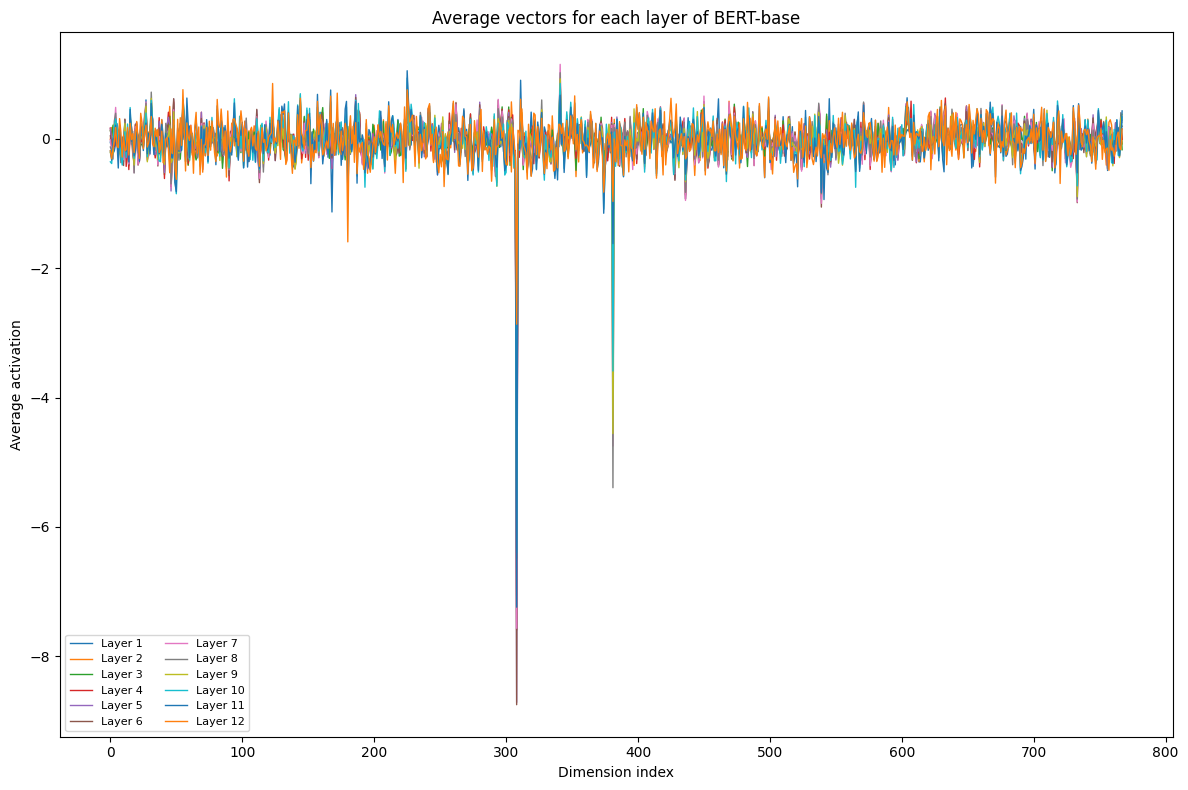

In [6]:
runner = BertHiddenStateRunner(
    model_name="bert-base-uncased",
    max_length=64,
)

texts = [
    "The cat is sleeping on the sofa.",
    "A transformer model produces contextualized embeddings.",
    "This paper studies positional artifacts in BERT.",
    "Layer normalization can amplify certain dimensions.",
    "The quick brown fox jumps over the lazy dog.",
] * 200  # petit corpus jouet

mean_vectors = compute_mean_vectors_over_corpus(
    runner=runner,
    texts=texts,
    batch_size=16,
    exclude_embedding_layer=True,
    remove_special_tokens=False,  # garde [CLS] au début
)

plot_mean_vectors(mean_vectors)

In [7]:
from collections import Counter
from typing import Tuple


def count_argmin_argmax_for_layer(
    flat_layer: FlattenedLayerData,
) -> Tuple[Counter, Counter]:
    """
    Count how often each dimension is the argmin / argmax
    across token embeddings of one layer.

    Returns:
        min_counter: Counter(dim -> count)
        max_counter: Counter(dim -> count)
    """
    embeddings = flat_layer.embeddings  # (N, d)

    min_dims = torch.argmin(embeddings, dim=1).tolist()
    max_dims = torch.argmax(embeddings, dim=1).tolist()

    min_counter = Counter(min_dims)
    max_counter = Counter(max_dims)

    return min_counter, max_counter

In [8]:
def dominant_outlier_stats_for_layer(
    flat_layer: FlattenedLayerData,
) -> dict:
    """
    Return the most frequent argmin / argmax dimensions and their proportions.
    """
    min_counter, max_counter = count_argmin_argmax_for_layer(flat_layer)
    n_tokens = flat_layer.embeddings.shape[0]

    top_min_dim, top_min_count = min_counter.most_common(1)[0]
    top_max_dim, top_max_count = max_counter.most_common(1)[0]

    return {
        "n_tokens": n_tokens,
        "top_min_dim": top_min_dim,
        "top_min_count": top_min_count,
        "top_min_ratio": top_min_count / n_tokens,
        "top_max_dim": top_max_dim,
        "top_max_count": top_max_count,
        "top_max_ratio": top_max_count / n_tokens,
        "min_counter": min_counter,
        "max_counter": max_counter,
    }

In [9]:
def compute_outlier_dimension_stats_over_corpus(
    runner: BertHiddenStateRunner,
    texts: List[str],
    batch_size: int = 16,
    exclude_embedding_layer: bool = True,
    remove_special_tokens: bool = False,
) -> Dict[int, dict]:
    """
    For each layer, count how often each dimension is argmin / argmax
    across all valid tokens in the corpus.
    """
    start_layer = 1 if exclude_embedding_layer else 0
    n_layers = 13  # bert-base

    layer_min_counters = {}
    layer_max_counters = {}
    layer_token_counts = {}

    for layer_idx in range(start_layer, n_layers):
        layer_min_counters[layer_idx] = Counter()
        layer_max_counters[layer_idx] = Counter()
        layer_token_counts[layer_idx] = 0

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_out = runner.run_batch(batch_texts)

        for layer_idx in range(start_layer, n_layers):
            flat = flatten_valid_tokens(
                batch_output=batch_out,
                layer_idx=layer_idx,
                remove_special_tokens=remove_special_tokens,
            )

            min_counter, max_counter = count_argmin_argmax_for_layer(flat)

            layer_min_counters[layer_idx].update(min_counter)
            layer_max_counters[layer_idx].update(max_counter)
            layer_token_counts[layer_idx] += flat.embeddings.shape[0]

    results = {}

    for layer_idx in range(start_layer, n_layers):
        n_tokens = layer_token_counts[layer_idx]
        min_counter = layer_min_counters[layer_idx]
        max_counter = layer_max_counters[layer_idx]

        top_min_dim, top_min_count = min_counter.most_common(1)[0]
        top_max_dim, top_max_count = max_counter.most_common(1)[0]

        results[layer_idx] = {
            "n_tokens": n_tokens,
            "top_min_dim": top_min_dim,
            "top_min_count": top_min_count,
            "top_min_ratio": top_min_count / n_tokens,
            "top_max_dim": top_max_dim,
            "top_max_count": top_max_count,
            "top_max_ratio": top_max_count / n_tokens,
            "min_counter": min_counter,
            "max_counter": max_counter,
        }

    return results

In [10]:
def print_outlier_stats(results: Dict[int, dict]):
    for layer_idx, stats in results.items():
        print(f"Layer {layer_idx}")
        print(f"  n_tokens      : {stats['n_tokens']}")
        print(
            f"  top min dim   : {stats['top_min_dim']} "
            f"({stats['top_min_ratio']:.2%})"
        )
        print(
            f"  top max dim   : {stats['top_max_dim']} "
            f"({stats['top_max_ratio']:.2%})"
        )
        print()

In [11]:
outlier_stats = compute_outlier_dimension_stats_over_corpus(
    runner=runner,
    texts=texts,
    batch_size=16,
    exclude_embedding_layer=True,
    remove_special_tokens=False,
)

print_outlier_stats(outlier_stats)

Layer 1
  n_tokens      : 12000
  top min dim   : 308 (78.33%)
  top max dim   : 139 (8.33%)

Layer 2
  n_tokens      : 12000
  top min dim   : 308 (95.00%)
  top max dim   : 139 (5.00%)

Layer 3
  n_tokens      : 12000
  top min dim   : 308 (83.33%)
  top max dim   : 545 (8.33%)

Layer 4
  n_tokens      : 12000
  top min dim   : 308 (90.00%)
  top max dim   : 514 (8.33%)

Layer 5
  n_tokens      : 12000
  top min dim   : 308 (90.00%)
  top max dim   : 341 (6.67%)

Layer 6
  n_tokens      : 12000
  top min dim   : 308 (90.00%)
  top max dim   : 341 (8.33%)

Layer 7
  n_tokens      : 12000
  top min dim   : 308 (88.33%)
  top max dim   : 341 (15.00%)

Layer 8
  n_tokens      : 12000
  top min dim   : 308 (85.00%)
  top max dim   : 341 (11.67%)

Layer 9
  n_tokens      : 12000
  top min dim   : 308 (80.00%)
  top max dim   : 341 (10.00%)

Layer 10
  n_tokens      : 12000
  top min dim   : 308 (86.67%)
  top max dim   : 123 (10.00%)

Layer 11
  n_tokens      : 12000
  top min dim   : 308 

In [12]:
def top_k_dims(counter: Counter, k: int = 10):
    return counter.most_common(k)

In [17]:
layer_1_min_top10 = top_k_dims(outlier_stats[3]["min_counter"], k=10)
print(layer_1_min_top10)

[(308, 10000), (381, 1000), (621, 200), (374, 200), (597, 200), (191, 200), (50, 200)]


In [18]:
from dataclasses import replace
from typing import Iterable, List, Dict, Union
import torch


def clip_embedding_dimensions(
    embeddings: torch.Tensor,
    dims_to_clip: Union[int, Iterable[int]],
) -> torch.Tensor:
    """
    Return a clipped copy of embeddings by zeroing selected dimensions.

    Args:
        embeddings: Tensor of shape (N, d) or (..., d)
        dims_to_clip: int or iterable of ints

    Returns:
        A new tensor with selected dimensions set to zero.
    """
    if isinstance(dims_to_clip, int):
        dims_to_clip = [dims_to_clip]
    else:
        dims_to_clip = list(dims_to_clip)

    clipped = embeddings.clone()
    clipped[..., dims_to_clip] = 0.0
    return clipped

In [19]:
def clip_flattened_layer_data(
    flat_layer: FlattenedLayerData,
    dims_to_clip: Union[int, Iterable[int]],
) -> FlattenedLayerData:
    """
    Return a new FlattenedLayerData with clipped embeddings.
    """
    clipped_embeddings = clip_embedding_dimensions(
        flat_layer.embeddings,
        dims_to_clip=dims_to_clip,
    )

    return FlattenedLayerData(
        embeddings=clipped_embeddings,
        positions=flat_layer.positions.clone(),
        batch_indices=flat_layer.batch_indices.clone(),
        token_indices=flat_layer.token_indices.clone(),
        token_strings=list(flat_layer.token_strings),
    )

In [20]:
def select_primary_outlier_dims(
    layer_stats: dict,
    mode: str = "min",
) -> List[int]:
    """
    Select primary outlier dimensions from one layer stats dict.

    mode:
        - "min": take top_min_dim
        - "max": take top_max_dim
        - "both": take both
    """
    if mode == "min":
        return [layer_stats["top_min_dim"]]
    elif mode == "max":
        return [layer_stats["top_max_dim"]]
    elif mode == "both":
        dims = [layer_stats["top_min_dim"], layer_stats["top_max_dim"]]
        # remove duplicates if min=max
        return sorted(set(dims))
    else:
        raise ValueError(f"Unknown mode: {mode}")

In [21]:
def compare_outlier_stats_before_after_clipping(
    flat_layer: FlattenedLayerData,
    dims_to_clip: Union[int, Iterable[int]],
) -> Dict[str, dict]:
    """
    Compare dominant argmin/argmax stats before and after clipping.
    """
    before = dominant_outlier_stats_for_layer(flat_layer)
    clipped_flat = clip_flattened_layer_data(flat_layer, dims_to_clip=dims_to_clip)
    after = dominant_outlier_stats_for_layer(clipped_flat)

    return {
        "before": before,
        "after": after,
        "dims_clipped": list([dims_to_clip] if isinstance(dims_to_clip, int) else dims_to_clip),
    }

In [22]:
def print_before_after_comparison(comparison: Dict[str, dict]):
    before = comparison["before"]
    after = comparison["after"]
    dims_clipped = comparison["dims_clipped"]

    print(f"Clipped dims: {dims_clipped}")
    print("Before clipping:")
    print(
        f"  top min dim: {before['top_min_dim']} ({before['top_min_ratio']:.2%}), "
        f"top max dim: {before['top_max_dim']} ({before['top_max_ratio']:.2%})"
    )
    print("After clipping:")
    print(
        f"  top min dim: {after['top_min_dim']} ({after['top_min_ratio']:.2%}), "
        f"top max dim: {after['top_max_dim']} ({after['top_max_ratio']:.2%})"
    )

In [23]:
batch_out = runner.run_batch(texts[:16])

# Layer 1 if excluding embedding layer conventionally
flat_l1 = flatten_valid_tokens(
    batch_output=batch_out,
    layer_idx=1,
    remove_special_tokens=False,
)

stats_l1 = dominant_outlier_stats_for_layer(flat_l1)
dims_to_clip = select_primary_outlier_dims(stats_l1, mode="min")

comparison = compare_outlier_stats_before_after_clipping(
    flat_layer=flat_l1,
    dims_to_clip=dims_to_clip,
)

print_before_after_comparison(comparison)

Clipped dims: [308]
Before clipping:
  top min dim: 308 (78.95%), top max dim: 139 (8.42%)
After clipping:
  top min dim: 168 (23.68%), top max dim: 139 (8.42%)


In [25]:
import torch
import torch.nn.functional as F
from typing import Optional, Dict


def mean_random_pairwise_cosine(
    embeddings: torch.Tensor,
    n_pairs: int = 1000,
    seed: Optional[int] = 42,
) -> float:
    """
    Estimate anisotropy as the mean cosine similarity between random pairs of embeddings.

    Args:
        embeddings: Tensor of shape (N, d)
        n_pairs: number of random pairs to sample
        seed: random seed for reproducibility

    Returns:
        Mean cosine similarity over sampled pairs.
    """
    if embeddings.ndim != 2:
        raise ValueError(f"Expected embeddings of shape (N, d), got {embeddings.shape}")

    n_tokens = embeddings.shape[0]
    if n_tokens < 2:
        raise ValueError("Need at least 2 embeddings to compute pairwise cosine similarity.")

    g = torch.Generator()
    if seed is not None:
        g.manual_seed(seed)

    idx1 = torch.randint(0, n_tokens, (n_pairs,), generator=g)
    idx2 = torch.randint(0, n_tokens, (n_pairs,), generator=g)

    # éviter trop de paires identiques
    same = idx1 == idx2
    while same.any():
        idx2[same] = torch.randint(0, n_tokens, (same.sum().item(),), generator=g)
        same = idx1 == idx2

    x1 = embeddings[idx1]   # (n_pairs, d)
    x2 = embeddings[idx2]   # (n_pairs, d)

    cos = F.cosine_similarity(x1, x2, dim=1)
    return cos.mean().item()

In [26]:
def anisotropy_before_after_clipping(
    flat_layer: FlattenedLayerData,
    dims_to_clip,
    n_pairs: int = 1000,
    seed: Optional[int] = 42,
) -> Dict[str, float]:
    """
    Compare anisotropy before and after clipping selected dimensions.
    """
    before_score = mean_random_pairwise_cosine(
        flat_layer.embeddings,
        n_pairs=n_pairs,
        seed=seed,
    )

    clipped_flat = clip_flattened_layer_data(
        flat_layer=flat_layer,
        dims_to_clip=dims_to_clip,
    )

    after_score = mean_random_pairwise_cosine(
        clipped_flat.embeddings,
        n_pairs=n_pairs,
        seed=seed,
    )

    return {
        "before": before_score,
        "after": after_score,
        "delta": after_score - before_score,
    }

In [27]:
def collect_layer_embeddings_over_corpus(
    runner: BertHiddenStateRunner,
    texts,
    layer_idx: int,
    batch_size: int = 16,
    remove_special_tokens: bool = False,
) -> torch.Tensor:
    """
    Collect all valid token embeddings for one layer over a corpus.
    Returns a tensor of shape (N, d).
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_out = runner.run_batch(batch_texts)

        flat = flatten_valid_tokens(
            batch_output=batch_out,
            layer_idx=layer_idx,
            remove_special_tokens=remove_special_tokens,
        )

        all_embeddings.append(flat.embeddings)

    if not all_embeddings:
        raise ValueError("No embeddings collected from corpus.")

    return torch.cat(all_embeddings, dim=0)

In [28]:
def collect_layer_embeddings_over_corpus(
    runner: BertHiddenStateRunner,
    texts,
    layer_idx: int,
    batch_size: int = 16,
    remove_special_tokens: bool = False,
) -> torch.Tensor:
    """
    Collect all valid token embeddings for one layer over a corpus.
    Returns a tensor of shape (N, d).
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_out = runner.run_batch(batch_texts)

        flat = flatten_valid_tokens(
            batch_output=batch_out,
            layer_idx=layer_idx,
            remove_special_tokens=remove_special_tokens,
        )

        all_embeddings.append(flat.embeddings)

    if not all_embeddings:
        raise ValueError("No embeddings collected from corpus.")

    return torch.cat(all_embeddings, dim=0)

In [29]:
def anisotropy_all_layers_before_after(
    runner: BertHiddenStateRunner,
    texts,
    outlier_stats: Dict[int, dict],
    batch_size: int = 16,
    remove_special_tokens: bool = False,
    exclude_embedding_layer: bool = True,
    clip_mode: str = "min",
    n_pairs: int = 1000,
    seed: Optional[int] = 42,
) -> Dict[int, Dict[str, float]]:
    """
    Compute anisotropy before/after clipping for all layers.
    """
    start_layer = 1 if exclude_embedding_layer else 0
    n_layers = 13

    results = {}

    for layer_idx in range(start_layer, n_layers):
        layer_embeddings = collect_layer_embeddings_over_corpus(
            runner=runner,
            texts=texts,
            layer_idx=layer_idx,
            batch_size=batch_size,
            remove_special_tokens=remove_special_tokens,
        )

        dims_to_clip = select_primary_outlier_dims(
            outlier_stats[layer_idx],
            mode=clip_mode,
        )

        before_score = mean_random_pairwise_cosine(
            layer_embeddings,
            n_pairs=n_pairs,
            seed=seed,
        )

        clipped_embeddings = clip_embedding_dimensions(
            layer_embeddings,
            dims_to_clip=dims_to_clip,
        )

        after_score = mean_random_pairwise_cosine(
            clipped_embeddings,
            n_pairs=n_pairs,
            seed=seed,
        )

        results[layer_idx] = {
            "before": before_score,
            "after": after_score,
            "delta": after_score - before_score,
            "dims_clipped": dims_to_clip,
        }

    return results

In [31]:
def print_anisotropy_results(results: Dict[int, Dict[str, float]]):
    for layer_idx, res in results.items():
        print(f"Layer {layer_idx}")
        print(f"  clipped dims : {res['dims_clipped']}")
        print(f"  before       : {res['before']:.6f}")
        print(f"  after        : {res['after']:.6f}")
        print(f"  delta        : {res['delta']:.6f}")
        print()

In [32]:
import matplotlib.pyplot as plt


def plot_anisotropy_before_after(
    results: Dict[int, Dict[str, float]],
    title: str = "Anisotropy before and after clipping",
):
    layers = sorted(results.keys())
    before = [results[l]["before"] for l in layers]
    after = [results[l]["after"] for l in layers]

    plt.figure(figsize=(8, 5))
    plt.plot(layers, before, marker="o", label="Before clipping")
    plt.plot(layers, after, marker="o", label="After clipping")
    plt.xlabel("Layer")
    plt.ylabel("Mean cosine similarity")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

Layer 1
  clipped dims : [308]
  before       : 0.187561
  after        : 0.096944
  delta        : -0.090617

Layer 2
  clipped dims : [308]
  before       : 0.245137
  after        : 0.099419
  delta        : -0.145718

Layer 3
  clipped dims : [308]
  before       : 0.223144
  after        : 0.112804
  delta        : -0.110341

Layer 4
  clipped dims : [308]
  before       : 0.247070
  after        : 0.123073
  delta        : -0.123997

Layer 5
  clipped dims : [308]
  before       : 0.284131
  after        : 0.137463
  delta        : -0.146668

Layer 6
  clipped dims : [308]
  before       : 0.290147
  after        : 0.157097
  delta        : -0.133050

Layer 7
  clipped dims : [308]
  before       : 0.303140
  after        : 0.211068
  delta        : -0.092073

Layer 8
  clipped dims : [308]
  before       : 0.316634
  after        : 0.254349
  delta        : -0.062285

Layer 9
  clipped dims : [308]
  before       : 0.296040
  after        : 0.253695
  delta        : -0.042345

L

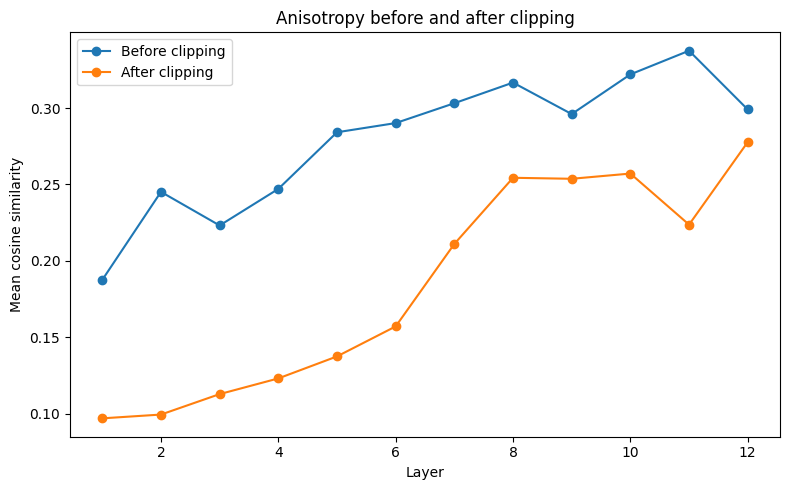

In [33]:
# 1. Détection des outliers sur le corpus
outlier_stats = compute_outlier_dimension_stats_over_corpus(
    runner=runner,
    texts=texts,
    batch_size=16,
    exclude_embedding_layer=True,
    remove_special_tokens=False,
)

# 2. Mesure d’anisotropie avant / après clipping
anisotropy_results = anisotropy_all_layers_before_after(
    runner=runner,
    texts=texts,
    outlier_stats=outlier_stats,
    batch_size=16,
    remove_special_tokens=False,
    exclude_embedding_layer=True,
    clip_mode="min",   # cohérent pour BERT-base au départ
    n_pairs=1000,
    seed=42,
)

# 3. Affichage
print_anisotropy_results(anisotropy_results)
plot_anisotropy_before_after(anisotropy_results)

In [34]:
from dataclasses import dataclass
from typing import List, Optional
import torch
from torch.utils.data import Dataset, DataLoader


@dataclass
class PositionProbeDatasetTensors:
    X: torch.Tensor   # (N, d)
    y: torch.Tensor   # (N,) positions / classes


def build_position_probe_tensors(
    runner: BertHiddenStateRunner,
    texts: List[str],
    layer_idx: int,
    batch_size: int = 16,
    remove_special_tokens: bool = False,
    max_position: int = 300,
) -> PositionProbeDatasetTensors:
    """
    Build a token-level dataset for position prediction from one layer.

    Keeps only tokens whose position < max_position.
    """
    all_X = []
    all_y = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_out = runner.run_batch(batch_texts)

        flat = flatten_valid_tokens(
            batch_output=batch_out,
            layer_idx=layer_idx,
            remove_special_tokens=remove_special_tokens,
        )

        # positions are token indices in the tokenized sequence
        keep = flat.positions < max_position

        if keep.any():
            all_X.append(flat.embeddings[keep])
            all_y.append(flat.positions[keep])

    if not all_X:
        raise ValueError("No examples kept for position probe.")

    X = torch.cat(all_X, dim=0)   # (N, d)
    y = torch.cat(all_y, dim=0)   # (N,)


    return PositionProbeDatasetTensors(X=X, y=y)

In [39]:
class PositionProbeDataset(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X = X.float()
        self.y = y.long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [36]:
import torch.nn as nn


class LinearPositionProbe(nn.Module):
    def __init__(self, input_dim: int = 768, num_classes: int = 300):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes, bias=False)

    def forward(self, x):
        return self.linear(x)

In [37]:
def split_probe_tensors(
    X: torch.Tensor,
    y: torch.Tensor,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    seed: int = 42,
):
    N = X.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(N, generator=g)

    X = X[perm]
    y = y[perm]

    n_train = int(train_ratio * N)
    n_val = int(val_ratio * N)

    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
    X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [40]:
def evaluate_probe(model, dataloader, device="cpu"):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb)
            loss = criterion(logits, yb)

            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.numel()
            loss_sum += loss.item() * yb.size(0)

    return {
        "loss": loss_sum / total,
        "acc": correct / total,
    }


def train_position_probe(
    train_dataset: PositionProbeDataset,
    val_dataset: PositionProbeDataset,
    input_dim: int = 768,
    num_classes: int = 300,
    batch_size: int = 128,
    num_epochs: int = 10,
    lr: float = 1e-3,
    device: Optional[str] = None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = LinearPositionProbe(input_dim=input_dim, num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_examples += yb.numel()
            total_loss += loss.item() * yb.size(0)

        train_metrics = {
            "loss": total_loss / total_examples,
            "acc": total_correct / total_examples,
        }
        val_metrics = evaluate_probe(model, val_loader, device=device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
        })

    return model, history

In [41]:
def contribution_vectors_for_dataset(
    probe_model: LinearPositionProbe,
    X: torch.Tensor,
    y: torch.Tensor,
    device: Optional[str] = None,
) -> torch.Tensor:
    """
    Compute contribution vectors c(i)=|w_i * v_i| for each example
    using the row of W corresponding to the true class y.

    Returns:
        contributions: (N, d)
    """
    device = device or next(probe_model.parameters()).device
    W = probe_model.linear.weight.detach().to(device)   # (num_classes, d)

    X = X.to(device)
    y = y.to(device)

    W_y = W[y]                    # (N, d)
    contributions = torch.abs(W_y * X)
    return contributions.detach().cpu()

In [42]:
def contribution_vectors_for_dataset(
    probe_model: LinearPositionProbe,
    X: torch.Tensor,
    y: torch.Tensor,
    device: Optional[str] = None,
) -> torch.Tensor:
    """
    Compute contribution vectors c(i)=|w_i * v_i| for each example
    using the row of W corresponding to the true class y.

    Returns:
        contributions: (N, d)
    """
    device = device or next(probe_model.parameters()).device
    W = probe_model.linear.weight.detach().to(device)   # (num_classes, d)

    X = X.to(device)
    y = y.to(device)

    W_y = W[y]                    # (N, d)
    contributions = torch.abs(W_y * X)
    return contributions.detach().cpu()

In [43]:
def mean_contribution_of_dim_by_position(
    probe_model: LinearPositionProbe,
    X: torch.Tensor,
    y: torch.Tensor,
    dim_idx: int,
    num_classes: int = 300,
    device: Optional[str] = None,
) -> torch.Tensor:
    """
    For one neuron dimension dim_idx, compute mean contribution by target position.
    Returns shape (num_classes,)
    """
    contributions = contribution_vectors_for_dataset(
        probe_model=probe_model,
        X=X,
        y=y,
        device=device,
    )  # (N, d)

    contrib_dim = contributions[:, dim_idx]   # (N,)
    out = torch.zeros(num_classes)
    counts = torch.zeros(num_classes)

    for pos in range(num_classes):
        mask = (y == pos)
        if mask.any():
            out[pos] = contrib_dim[mask].mean()
            counts[pos] = mask.sum()

    return out

In [44]:
def mean_contribution_of_dim_by_position(
    probe_model: LinearPositionProbe,
    X: torch.Tensor,
    y: torch.Tensor,
    dim_idx: int,
    num_classes: int = 300,
    device: Optional[str] = None,
) -> torch.Tensor:
    """
    For one neuron dimension dim_idx, compute mean contribution by target position.
    Returns shape (num_classes,)
    """
    contributions = contribution_vectors_for_dataset(
        probe_model=probe_model,
        X=X,
        y=y,
        device=device,
    )  # (N, d)

    contrib_dim = contributions[:, dim_idx]   # (N,)
    out = torch.zeros(num_classes)
    counts = torch.zeros(num_classes)

    for pos in range(num_classes):
        mask = (y == pos)
        if mask.any():
            out[pos] = contrib_dim[mask].mean()
            counts[pos] = mask.sum()

    return out

In [57]:
def run_single_layer_position_probe(
    runner,
    texts,
    layer_idx: int,
    max_position: int = 300,
    build_batch_size: int = 16,
    probe_batch_size: int = 128,
    num_epochs: int = 10,
    lr: float = 1e-3,
    remove_special_tokens: bool = False,
    seed: int = 42,
    device: str = None,
):
    train_texts, val_texts, test_texts = split_texts(texts, seed=seed)

    train_tensors = build_position_probe_tensors(
        runner=runner,
        texts=train_texts,
        layer_idx=layer_idx,
        batch_size=build_batch_size,
        remove_special_tokens=remove_special_tokens,
        max_position=max_position,
    )

    val_tensors = build_position_probe_tensors(
        runner=runner,
        texts=val_texts,
        layer_idx=layer_idx,
        batch_size=build_batch_size,
        remove_special_tokens=remove_special_tokens,
        max_position=max_position,
    )

    test_tensors = build_position_probe_tensors(
        runner=runner,
        texts=test_texts,
        layer_idx=layer_idx,
        batch_size=build_batch_size,
        remove_special_tokens=remove_special_tokens,
        max_position=max_position,
    )

    X_train, y_train = train_tensors.X, train_tensors.y
    X_val, y_val = val_tensors.X, val_tensors.y
    X_test, y_test = test_tensors.X, test_tensors.y

    train_ds = PositionProbeDataset(X_train, y_train)
    val_ds = PositionProbeDataset(X_val, y_val)
    test_ds = PositionProbeDataset(X_test, y_test)

    print("train unique positions:", torch.unique(y_train).numel())
    print("val unique positions:", torch.unique(y_val).numel())
    print("test unique positions:", torch.unique(y_test).numel())

    print("train min/max:", y_train.min().item(), y_train.max().item())
    print("val min/max:", y_val.min().item(), y_val.max().item())
    print("test min/max:", y_test.min().item(), y_test.max().item())

    model, history = train_position_probe(
        train_dataset=train_ds,
        val_dataset=val_ds,
        input_dim=X_train.shape[1],
        num_classes=max_position,
        batch_size=probe_batch_size,
        num_epochs=num_epochs,
        lr=lr,
        device=device,
    )

    test_loader = DataLoader(test_ds, batch_size=probe_batch_size, shuffle=False)
    test_metrics = evaluate_probe(
        model,
        test_loader,
        device=device or ("cuda" if torch.cuda.is_available() else "cpu"),
    )

    return {
        "model": model,
        "history": history,
        "test_metrics": test_metrics,
        "X_test": X_test,
        "y_test": y_test,
    }

In [49]:
def split_texts(
    texts,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    seed: int = 42,
):
    N = len(texts)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(N, generator=g).tolist()

    texts_shuffled = [texts[i] for i in perm]

    n_train = int(train_ratio * N)
    n_val = int(val_ratio * N)

    train_texts = texts_shuffled[:n_train]
    val_texts = texts_shuffled[n_train:n_train+n_val]
    test_texts = texts_shuffled[n_train+n_val:]

    return train_texts, val_texts, test_texts

In [58]:
probe_results = run_single_layer_position_probe(
    runner=runner,
    texts=texts,
    layer_idx=1,
    max_position=300,
    build_batch_size=16,
    probe_batch_size=128,
    num_epochs=10,
    lr=1e-3,
    remove_special_tokens=True,
)

print(probe_results["test_metrics"])

train unique positions: 13
val unique positions: 13
test unique positions: 13
train min/max: 1 13
val min/max: 1 13
test min/max: 1 13
{'loss': 0.0036717206100973024, 'acc': 1.0}


In [55]:
def run_probe_for_selected_layers(
    runner,
    texts,
    layers=(1, 6, 12),
    max_position: int = 300,
    build_batch_size: int = 16,
    probe_batch_size: int = 128,
    num_epochs: int = 10,
    lr: float = 1e-3,
    remove_special_tokens: bool = True,
    seed: int = 42,
    device: str = None,
):
    results = {}

    for layer_idx in layers:
        res = run_single_layer_position_probe(
            runner=runner,
            texts=texts,
            layer_idx=layer_idx,
            max_position=max_position,
            build_batch_size=build_batch_size,
            probe_batch_size=probe_batch_size,
            num_epochs=num_epochs,
            lr=lr,
            remove_special_tokens=remove_special_tokens,
            seed=seed,
            device=device,
        )
        results[layer_idx] = res["test_metrics"]
        print(f"Layer {layer_idx}: {res['test_metrics']}")

    return results

In [56]:
layer_probe_results = run_probe_for_selected_layers(
    runner=runner,
    texts=texts,
    layers=(1, 6, 12),
    remove_special_tokens=True,
)

Layer 1: {'loss': 0.003721967162869597, 'acc': 1.0}
Layer 6: {'loss': 0.002990374318485878, 'acc': 1.0}
Layer 12: {'loss': 0.008579434137033019, 'acc': 1.0}


In [60]:
print("num texts:", len(texts))
print("num unique texts:", len(set(texts)))
print(texts[:10])

num texts: 1000
num unique texts: 5
['The cat is sleeping on the sofa.', 'A transformer model produces contextualized embeddings.', 'This paper studies positional artifacts in BERT.', 'Layer normalization can amplify certain dimensions.', 'The quick brown fox jumps over the lazy dog.', 'The cat is sleeping on the sofa.', 'A transformer model produces contextualized embeddings.', 'This paper studies positional artifacts in BERT.', 'Layer normalization can amplify certain dimensions.', 'The quick brown fox jumps over the lazy dog.']
